# Workshop 11 - Introduction to Machine Learning

We've spent 10 weeks building up to being able to effectively run machine learning models in Python. We've learned `numpy`, `pandas`, and `seaborn`. Now we learn `sklearn`, the final boss of HPDM171.

In [1]:
# First run this to import useful packages - we will need PCA and Kmeans from sklearn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


Also, open a terminal instance and run

`pip install ucimlrepo`

We will be using the Breast Cancer Winconsin Dataset for most of this workshop, available at https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic. The dataset contains a number of features recorded from tumour cells that could potentially have been cancerous. Our job for this workshop will be to see if we can use unsupervised clustering to categorise the tumour cells, and interpret what these clusters could mean

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
df = data.frame
df = df.rename(columns={'target': 'diagnosis'}) # target is more common in machine learning, I prefer diagnosis as a name because it's more descriptive

### Task 1
Familiarise yourself with what's in this dataset

In [3]:
# your answers may vary but by week 11, you'll have your own preferences here

### Task 2
First, we are going to be using principal components to understand these variables. First, create a feature matrix `x_df` containing only the features (no Diagnosis) and scale it using `StandardScaler()`

In [4]:
# We just drop the diagnosis and then use the standard scalar function
x_df=df.drop('diagnosis',axis=1)
scaler = StandardScaler()
x_df_scaled = scaler.fit_transform(x_df)

### Task 3
Fit a principal components model with 2 PCs, and add these PCs as new columns to the dataframe called PCA1 and PCA2

In [5]:
# Create a pca model with 2 components and apply it to x_df_scaled
pca_model = PCA(n_components=2, random_state=42)
pca_model.fit(x_df_scaled)
x_2d=pca_model.transform(x_df_scaled)
# Put the result into df
df['PCA1']=x_2d[:,0]
df['PCA2']=x_2d[:,1]

### Task 4
Check the variance explained by each principal component, and the loadings for each variable

In [6]:
#This one is fairly standard
print("Explained variance ratio (PC1, PC2):", pca_model.explained_variance_ratio_[:2])

# This creates a very long table of pcs, I've written code to sort it by PC1 and PC2
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=x_df.columns,
    columns=['PC1', 'PC2']
)

print("\nLoadings sorted by importance for PC1:")
print(loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index))

print("\nLoadings sorted by importance for PC2:")
print(loadings.reindex(loadings['PC2'].abs().sort_values(ascending=False).index))

Explained variance ratio (PC1, PC2): [0.44272026 0.18971182]

Loadings sorted by importance for PC1:
                              PC1       PC2
mean concave points      0.260854 -0.034768
mean concavity           0.258400  0.060165
worst concave points     0.250886 -0.008257
mean compactness         0.239285  0.151892
worst perimeter          0.236640 -0.199878
worst concavity          0.228768  0.097964
worst radius             0.227997 -0.219866
mean perimeter           0.227537 -0.215181
worst area               0.224871 -0.219352
mean area                0.220995 -0.231077
mean radius              0.218902 -0.233857
perimeter error          0.211326 -0.089457
worst compactness        0.210096  0.143593
radius error             0.205979 -0.105552
area error               0.202870 -0.152293
concave points error     0.183417  0.130322
compactness error        0.170393  0.232716
concavity error          0.153590  0.197207
mean smoothness          0.142590  0.186113
mean symmetry      

### Task 5
Plot a scatterplot of the principal components, coloured by diagnosis

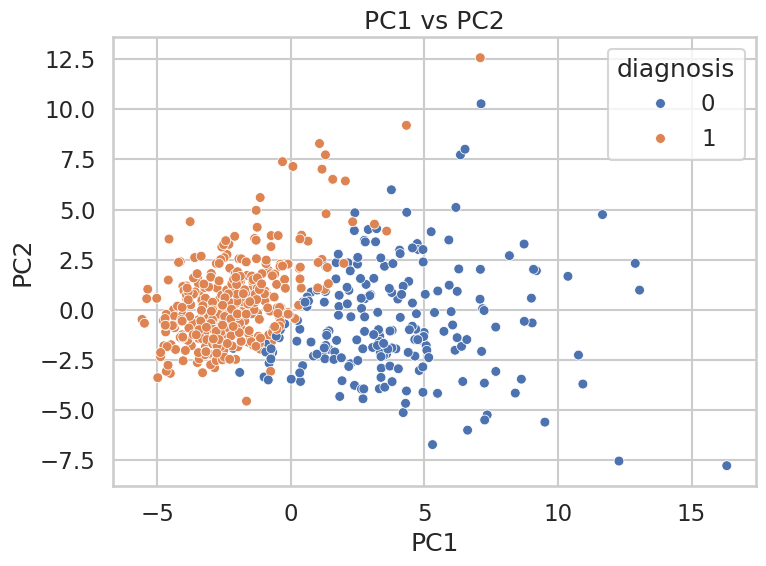

In [7]:
# I've done a lot of extra stuff here for style
plt.figure(figsize=(8,6))
sns.set_theme(context='talk',style='whitegrid')
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="diagnosis",
    s=50
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2")
plt.tight_layout()
plt.show()


# Read This
Our principal components are not based on any particular feature in the data. They are rather a combination of features that explain the data well. Here, PC1 is mostly driven by concavity-related variables and PC2 is largely driven by fractal-related variables.

People's data rarely clusters this nicely, espcially with biomarkers and demographics, but principal components work great in cellular biology and we can see a clear distinction between the clusters here. Now, we will try to automate classification using k-means clustering

### Task 6
Use a KMeans model with 2 clusters, add the predicted cluster on as another column

In [8]:
# this creates a model with 2 clusters, fits it using the data, and predicts the cluster
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(x_2d)
y_kmeans=kmeans.predict(x_2d)
df['cluster']=y_kmeans

### Task 7
Plot two scatterplots as subfigures, both with the principal components but one colour coded by predicted cluster and one by diagnosis

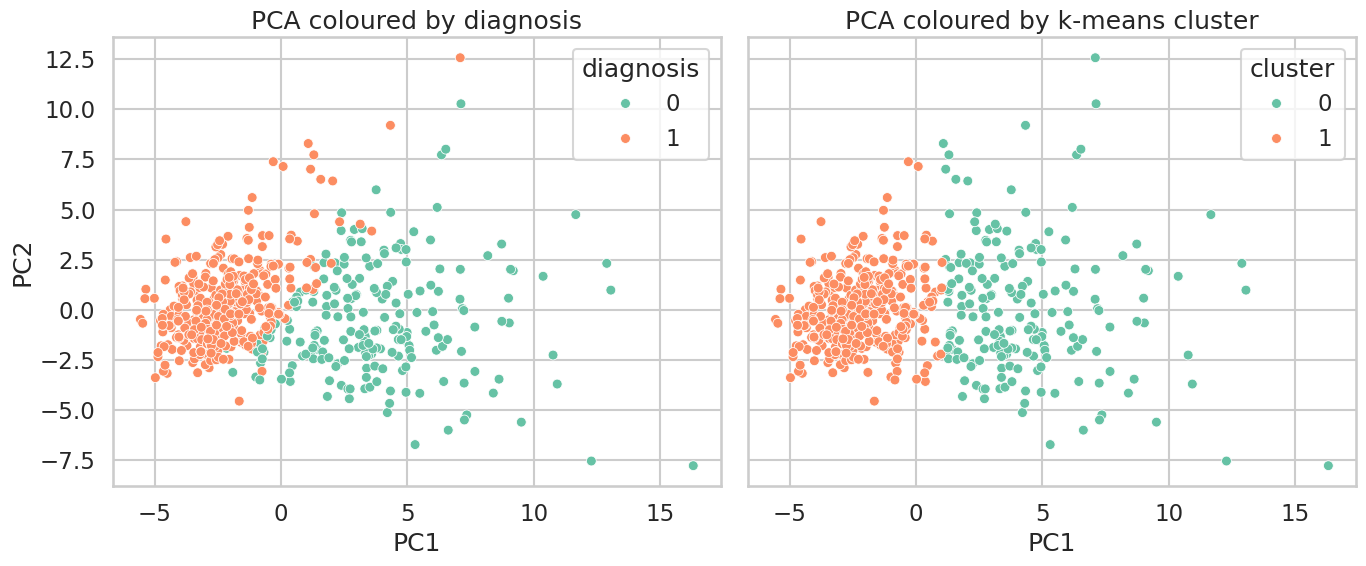

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

# Left: true diagnosis
sns.scatterplot(
    df,
    x="PCA1",
    y="PCA2",
    hue="diagnosis",
    s=50,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("PCA coloured by diagnosis")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Right: k-means clusters
sns.scatterplot(
    df,
    x="PCA1",
    y="PCA2",
    hue="cluster",
    s=50,
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("PCA coloured by k-means cluster")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

### Task 8
Use crosstab to match up the k means clusters with the diagnosis status and determine clustering accuracy

In [10]:
# we use crosstab with diagnosis and cluster, and then map to convert from cluster to predicted diagnosis
crosstab=pd.crosstab(df['diagnosis'],df['cluster'])
cluster_to_diag=crosstab.idxmax(axis=1).to_dict()
df['pred_diag']=df['cluster'].map(cluster_to_diag)
acc=accuracy_score(df['diagnosis'],df['pred_diag'])
print(acc)

0.9068541300527241


### Task 9
Display a confusion matrix to give more information

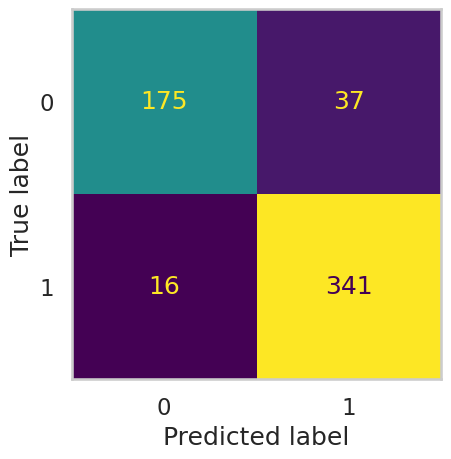

In [11]:
cm=confusion_matrix(df['diagnosis'],df['pred_diag'])
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=df['diagnosis'].unique())
disp.plot(colorbar=False)
plt.grid(False)
plt.show()

### Task 10

Run the below command to read in 3 more breast cancer samples

In [12]:
url = "https://raw.githubusercontent.com/hdg204/DoctorsAsDataScientists/main/new_breast_cancer_cases.csv"
new_cases = pd.read_csv(url)

Classify them using the pca and k means model from before

In [13]:
#we only need 3 commands here - scale the data, apply PCA, predict with kmeans
x_new_scaled = scaler.fit_transform(new_cases)
new_pca=pca_model.transform(x_new_scaled)
kmeans.predict(new_pca)

array([0, 0, 1], dtype=int32)

You should get the these are 0, 0, 1 for the predicted class. 

How do we know that this classification is accurate?

We can't. We don't have the target. But this is the endpoint of a predictive tool, you train it on data when you do know the outcome, so you can then use it to predict outcomes that you don't.

## Wine

Using principal components and k-means clustering we can categorise data into more than 2 groups (which makes it a lot different from logistic regression which you may have seen in HPDM182.

The UCI Wine Recognition dataset contains chemical compositions of wine from three grape cultivars:

* Barolo
* Grignolino
* Barbera

Read in the data using the code below

In [14]:
from sklearn.datasets import load_wine # this is the command that loads the data, this dataset is so commonly used for testing algorithms that it's bundled in with sklearn by default
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

cultivar_names = {0: "Barolo", 1: "Grignolino", 2: "Barbera"} # the original data just has class 0, class 1 and class 2
df = pd.DataFrame(X, columns=feature_names)
df["cultivar"] = pd.Series(y).map(cultivar_names)

Now use Principal Components Analysis and k-means clustering to build a model that can classify grape cultivar by chemical composition

* First, plot the first two principal components, colour coded by cultivar.
* Second, compute a confusion matrix for a k-means clustering algorithm with 3 clusters

Although this exercise might seem random, there are a lot of medical applications here, for example classifying people into disease type based on a full blood count

Variance explained: [0.36198848 0.1920749 ]


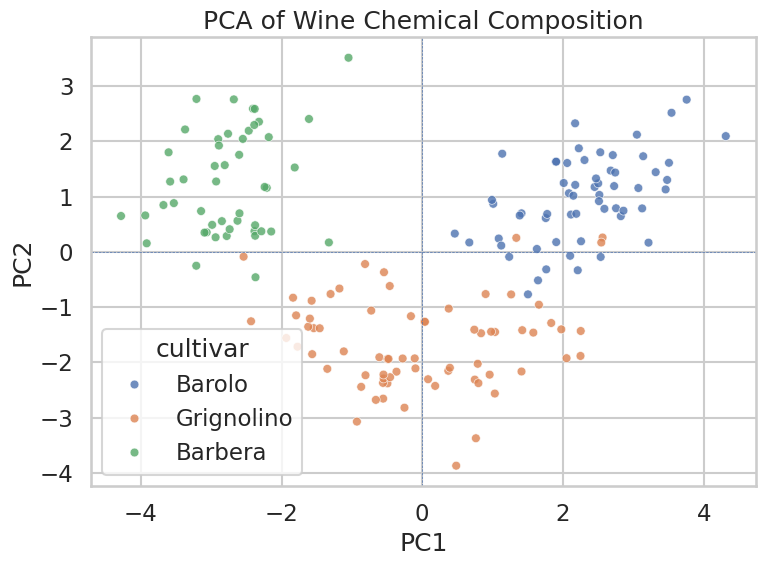

In [15]:
# first scale the features in the data
X_scaled = scaler.fit_transform(df[feature_names]) 

# make a pca model with 2 pcs and add it as columns
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print("Variance explained:", pca.explained_variance_ratio_)

# plot the pca with hue relating to composition to check how well things cluster by eye
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x="PC1", y="PC2",
    hue="cultivar", s=40, alpha=0.8
)
plt.title("PCA of Wine Chemical Composition")
plt.axhline(0, linestyle="--", linewidth=0.5)
plt.axvline(0, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

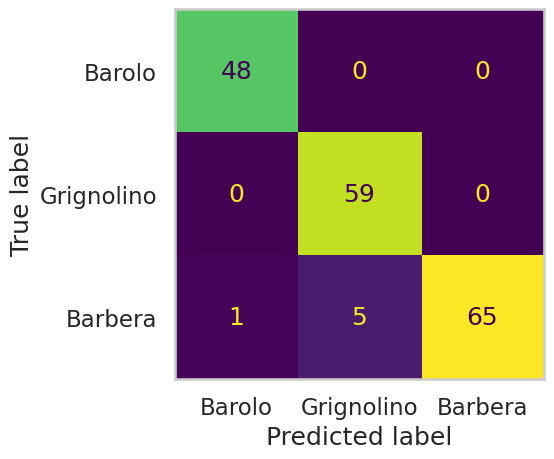

In [16]:
#fit a kmeans clustering algorithm and use crosstab to identify predicted clusters
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
df["cluster"] = kmeans.fit_predict(X_pca)
crosstab = pd.crosstab(df["cultivar"], df["cluster"])
cluster_to_cultivar = crosstab.idxmax(axis=0).to_dict()
df["predicted_cultivar"] = df["cluster"].map(cluster_to_cultivar)

# calculate confusion matrix and plot
cm=confusion_matrix(df['cultivar'],df['predicted_cultivar'])
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=df['cultivar'].unique())
disp.plot(colorbar=False)
plt.grid(False)
plt.show()
